In [417]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so
import math


cpu = pd.read_csv("../results/cpuScaling.csv", skip_blank_lines=True)
# gpu = cpu[cpu["executor"] == "gpu"]

# cellbased = pd.read_csv("../results/CellbasedCPUScaling.csv", skip_blank_lines=True)
strategies = list(cpu["strategy"].unique())



In [420]:
def setup_df(base_df: pd.DataFrame) -> pd.DataFrame:
    base_df["cells"] = [int(x.rsplit("/", 2)[1]) ** 3 for x in base_df["case_long"]]
    base_df["ms_normed"] = base_df["time_mean_ms"] / base_df["cells"]
    base_df = base_df[base_df["executor"] == "cpu"]
    base_df["Threads"] = [
        int(x.split("-")[1]) if x.split("-")[1] != "serial" else 1
        for x in base_df["variant"]
    ]
    base_df["cellsPerCpu"] = base_df["cells"] / base_df["Threads"]
    base_df["logth"] = [int(math.log2(x)) for x in base_df["Threads"]]
    group_cols = [
        "case_long",
        "strategy",
        "language",
        "precision",
        "executor",
        "use_kernelAbstractions",
        "use_fusing",
    ]

    baseline = (
        base_df[base_df["variant"].str.contains("serial")]
        .groupby(group_cols, as_index=False)["time_mean_ms"]
        .first()
        .rename(columns={"time_mean_ms": "serial_time"})
    )

    base_df = base_df.merge(baseline, on=group_cols, how="left")
    base_df["speedup"] = base_df["serial_time"] / base_df["time_mean_ms"]
    base_df["efficiency"] = base_df["speedup"] / base_df["Threads"]

    sb.set_theme()
    base_df["logthp1"] = base_df["logth"] + 1
    mapping = {
        "faceBased": "Face-Based",
        "globalFaceBased": "Face-Based Global",
        "batchedFace": "Face-Based Batched",
        "cellBased": "Cell-Based",
        "optimal": "Ideal Speedup",
    }
    bins = [0, 50000, 100000, 300000, 500000, max(base_df["cellsPerCpu"])]
    labels = ["0-50k", "50k-100k", "100k-300k", "300k-500k", "500k+"]

    base_df["CPTranges"] = pd.cut(base_df["cellsPerCpu"], bins=bins, labels=labels)
    base_df["case_num"] = base_df["case_long"].str.extract(r"(\d+)/?$").astype(int)

    # build sorted order
    order = (
        base_df[["case_long", "case_num"]]
        .drop_duplicates()
        .sort_values("case_num")["case_long"]
    )
    ncells = sorted((round(base_df["cells"] ** (1 / 3))).unique().astype(int))
    strats = ["faceBased", "globalFaceBased", "batchedFace", "cellBased"]
    base_df["avg_time"] = base_df.groupby(["Threads", "strategy"])[
    "speedup"
    ].transform("mean")
    base_df["avg_speedup"] = base_df.groupby(["Threads", "strategy"])[
        "speedup"
    ].transform("mean")
    base_df["avg_efficiency"] = base_df.groupby(["Threads", "strategy"])[
        "efficiency"
    ].transform("mean")
    base_df["avg_normed"] = base_df.groupby(["cells", "strategy"])[
        "ms_normed"
    ].transform("mean")
    base_df["sThreds"] = [f"{x}" for x in base_df["Threads"]]
    base_df["strategy_display"] = [mapping[s] for s in base_df["strategy"]]
    tmap = {np.int64(1): 0,
        np.int64(2): 1,
        np.int64(4): 2,
        np.int64(8): 3,
        np.int64(16): 4,
        np.int64(24): 5,
        np.int64(32): 6,
        np.int64(64): 7,
        np.int64(128): 8,
        np.int64(256): 9}
    base_df["threadindex"] = base_df["Threads"].apply(lambda x: tmap[x]+1)

    return base_df

In [421]:
cpu = setup_df(cpu)
# cellbased = setup_df(cellbased)


In [ ]:
def scaleplot(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y=yvar, ax=ax)
    plot.set_title(strategy)
    return plot

In [ ]:
def pareff(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y="efficiency", ax=ax)
    plot.set_title(strategy)
    return plot

In [ ]:
fig, axes = plt.subplots(3,4, figsize=(20, 10), sharey=False, sharex=False)

for i, strat in enumerate(strategies):
    plot = sb.lineplot(data=base_df[base_df["strategy"] == strat], x="logth", y="efficiency", ax=axes.flat[i])
    plot.set_title(strat.capitalize())
    plot.set_xticklabels(base_df["Threads"].unique())
    plot.set(
        xlabel=""
    )
    plot.set_xticks(base_df["logth"].unique())
    plot = sb.lineplot(data=base_df[base_df["strategy"] == strat], x="Threads", y="speedup", ax=axes.flat[i+4])
    axes.flat[i+4].plot([math.log2(x) for x in range(1,128)], linestyle="--", label="ideal")
    # plot.set(xscale="log")
    axes.flat[i+4].set_xscale('log', base=2)
    plot.set_ylim([0, 5])


    plot.set_xticks(base_df["Threads"].unique())
    plot.set_xticklabels(base_df["Threads"].unique())
    plot.set(
        xlabel="Threads"
    )
    plot = sb.lineplot(data=base_df[base_df["strategy"] == strat], x="cellsPerCpu", y="efficiency", ax=axes.flat[i+8], legend=False, markers=True, style="case_long", hue="case_long")
    plot.set(
        xlabel="Cells Per Thread"
    )
    plot.set(xscale="log")
    # plot.set_xticklabels(df["Threads"].unique())
    # plot.set_xticks(df["logth"].unique())
    # axes.flat[i+8].ticklabel_format(useOffset=False, style='plain')

plt.tight_layout()
plt.savefig("../figures/cpu_scaling.svg")

In [ ]:
plot = sb.relplot(data=base_df, x="cellsPerCpu", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
plt.tight_layout()

In [ ]:
plot = sb.relplot(data=base_df, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
plt.tight_layout()

In [ ]:
plot = sb.relplot(data=base_df, x="Threads", y="efficiency", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(base_df["Threads"].unique())

    ax.set_xticklabels(labels=base_df["Threads"].unique())

plt.tight_layout()

In [ ]:
plot = sb.relplot(data=base_df, x="Threads", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(base_df["Threads"].unique())

    ax.set_xticklabels(labels=base_df["Threads"].unique())

plt.tight_layout()

In [ ]:
base_df[base_df["case_long"] == "cases/Lid-Driven-Cavities/240/"]

In [ ]:
plot = sb.relplot(data=base_df[base_df["case_long"] == "cases/Lid-Driven-Cavities/240/"], x="Threads", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(base_df["Threads"].unique())

    ax.set_xticklabels(labels=base_df["Threads"].unique())

plt.tight_layout()

In [ ]:
plot = sb.relplot(data=base_df[base_df["case_long"] == "cases/Lid-Driven-Cavities/240/"], x="Threads", y="time_mean_ms", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(base_df["Threads"].unique())

    ax.set_xticklabels(labels=base_df["Threads"].unique())

plt.tight_layout()

In [ ]:
plot = sb.relplot(data=base_df[(base_df["Threads"] <= 16) & (base_df["Threads"] > 1)], x="cellsPerCpu", y="speedup", hue="Threads", kind="line", err_style=None, col="strategy", facet_kws={'sharey': True, 'sharex': True})
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

# for ax in plot.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.set_xticks(df["Threads"].unique())

#     ax.set_xticklabels(labels=df["Threads"].unique())

plt.tight_layout()

In [ ]:
yvar = "speedup"

plot = sb.relplot(data=base_df, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", col="strategy", legend=False, err_style=None,)
axes = plot.axes.flat
T = base_df["Threads"].unique()
# plot.set(xlabel="Threads")
# for ax in axes:
#     ax.set_xticks(list(range(1,9)))
#     ax.set_xticklabels(labels=T)
#     ax.plot([1,7], [1,7], color='r',linestyle="dashed")
#     ax.set_yticks(list(range(1,9)))
#     ax.set_yticklabels(labels=T)
# for col_val, ax in plot.axes_dict.items():
#     ax1 = ax.twinx()
#     ax1.grid(False)
#     sb.lineplot(data=df[df['strategy'] == col_val], x="logthp1", y="efficiency", ax=ax1, color="gray",)
#     ax1.set_ylabel('')
#     # subset data for this facet
#     sub = df[
#         (df["strategy"] == col_val)
#     ]

    # if not sub.empty:
    #     # find row with max y
    #     # idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
    #     # max_row = sub.loc[idx]
    #     # print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
    #     # annotate
    #     ax.text(
    #         max_row["logthp1"],
    #         max_row[yvar],
    #         f"{round(max_row[yvar], 3)}",
    #         color="black",
    #         fontsize=9,
    #         ha="left",
    #         va="bottom"
    #     )
    #     ax.scatter(
    #         max_row["logthp1"],
    #         max_row[yvar],
    #         color="red",
    #         s=50,
    #         zorder=5
    #     )
plt.xscale("log")
plt.tight_layout()

In [ ]:
plot = sb.relplot(data=base_df, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", col="strategy", legend=False)
axes = plot.axes.flat
T = base_df["Threads"].unique()
# plot.set(xscale="log")
plt.xlim([0, 1000000])
for ax in axes:
    labels = ax.get_xticklabels() # get x labels
plt.gca().ticklabel_format(axis='x', style='plain')


In [ ]:
yvar = "speedup"
plot = sb.relplot(data=base_df, x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", row="CPTranges", legend=False)
axes = plot.axes.flat
T = base_df["Threads"].unique()
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,9)))
    # ax.set_xticklabels(labels=T)
    ax.plot([1,7], [1,7], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,9)))
    ax.set_yticklabels(labels=T)
max_df = base_df.loc[base_df.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]
print(f"{len(max_df)} == {len(axes)}")
plt.xlim([0, 10])
# Loop through each facet
for (row_val, col_val), ax in plot.axes_dict.items():
    # subset data for this facet
    sub = base_df[
        (base_df["CPTranges"] == row_val) &
        (base_df["strategy"] == col_val)
    ]

    if not sub.empty:
        # find row with max y
        idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
        max_row = sub.loc[idx]
        print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
        # annotate
        ax.text(
            max_row["logthp1"],
            max_row[yvar],
            f"{round(max_row[yvar], 3)}",
            color="black",
            fontsize=9,
            ha="left",
            va="bottom"
        )
        ax.scatter(
            max_row["logthp1"],
            max_row[yvar],
            color="red",
            s=50,
            zorder=5
        )

In [ ]:
print(base_df["logth"].unique())
print(base_df["Threads"].unique())

In [ ]:
base_df

In [ ]:
yvar = "speedup"
plot = sb.relplot(data=base_df[base_df["variant"].str.contains("SOAFusedFaceBased")], x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", legend=False)
T = base_df["Threads"].unique()
axes = plot.axes.flat
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    # ax.set_xticklabels(labels=T)
    # ax.plot([1,10], [1,10], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    ax.set_yticklabels(labels=T)


In [ ]:
yvar = "efficiency"
plot = sb.relplot(data=base_df[base_df["variant"].str.contains("SOAFusedFaceBased")], x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", legend=False)
axes = plot.axes.flat
T = base_df["Threads"].unique()
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    # ax.set_xticklabels(labels=T)
    ax.plot([1,7], [1,7], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    ax.set_yticklabels(labels=T)
max_df = base_df.loc[base_df.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]
print(f"{len(max_df)} == {len(axes)}")
plt.xlim([0, 10])
# Loop through each facet
# for (row_val, col_val), ax in plot.axes_dict.items():
#     # subset data for this facet
#     sub = df[
#         (df["CPTranges"] == row_val) &
#         (df["strategy"] == col_val)
#     ]

#     if not sub.empty:
#         # find row with max y
#         idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
#         max_row = sub.loc[idx]
#         print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
#         # annotate
#         ax.text(
#             max_row["logthp1"],
#             max_row[yvar],
#             f"{round(max_row[yvar], 3)}",
#             color="black",
#             fontsize=9,
#             ha="left",
#             va="bottom"
#         )
#         ax.scatter(
#             max_row["logthp1"],
#             max_row[yvar],
#             color="red",
#             s=50,
#             zorder=5
#         )

In [ ]:
yvar = "ms_normed"
plot = sb.relplot(data=base_df[base_df["Threads"] != 0], x="logthp1", y=yvar, hue="strategy", kind="line", err_style=None,col="strategy", legend=False)
axes = plot.axes.flat
T = base_df["Threads"].unique()
plot.set(xlabel="Threads")
plt.yscale("log")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
    # ax.plot([2,8], [2,8], color='r',linestyle="dashed")
    # ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)
max_df = base_df.loc[base_df.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]

plot2 = sb.relplot(data=base_df[base_df["Threads"] != 0], x="logthp1", y="efficiency", hue="strategy", kind="line", err_style=None,col="strategy", legend=False)
for ax in plot2.axes.flat:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
plot3 = sb.relplot(data=base_df[base_df["Threads"] != 0], x="logthp1", y="speedup", hue="strategy", kind="line", err_style=None,col="strategy", legend=False)

for ax in plot3.axes.flat:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
    ax.plot([1,8], [1,8], color='r',linestyle="dashed")
    # ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)

In [ ]:
plot = sb.relplot(data=base_df, x="logthp1", y="speedup", kind="line", col="strategy", row="case_long", row_order=order, col_order=strats)
axes = plot.axes
for i in range(len(order)):
    for j in range(4):
        ax = axes[i,j]
        ax.set_title(f"{strats[j].capitalize()} with ${ncells[i]}^3$ cells")
        ax.tick_params(labelbottom=True)
        ax.set_xticks(list(range(1,10)))
        ax.set_xticklabels(labels=base_df["Threads"].unique())
        ax.plot([1,9], [1,9], color='r',linestyle="dashed")
        ax.set_yticks(list(range(1,10)))
        # ax.set_yticklabels(labels=T)
plt.tight_layout()

In [ ]:
plot = sb.relplot(data=base_df, x="logthp1", y="speedup", kind="line", col="strategy",  col_order=strats)
axes = plot.axes.flat

for i, ax in enumerate(axes):
    ax.set_title(f"{strats[i].capitalize()}")
    ax.tick_params(labelbottom=True)
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=base_df["Threads"].unique())
    ax.set_xlabel("Threads")
    ax.plot([1,9], [1,9], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)
plt.suptitle("Strong Scaling: Average over all case sizes")
plt.tight_layout()

In [ ]:
base_df

In [ ]:
def scaling_ms(data):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)

    with sb.plotting_context("paper", font_scale=1.5):
        plot = sb.relplot(data=data, x="logthp1", y="time_mean_ms", kind="scatter", style="strategy", hue="strategy",s=60)
        axes = plot.axes.flat

        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data,
                x="logthp1",
                y="time_mean_ms",
                hue="strategy",
                legend=False,   # avoid duplicate legends
                ax=ax
            )
            ax.tick_params(labelbottom=True)
            ax.set_xticks(list(range(1,10)))
            ax.set_xticklabels(labels=data["Threads"].unique())
            ax.set_xlabel("Threads")
            ax.plot([1,9], [1,9], color='k',linestyle="dashed", label="Ideal Speedup")
            ax.set_yticks(list(range(1,10)))

            # plot.legend(False)
        # sb.move_legend(plot, "upper left", bbox_to_anchor=(0.1 ,0.9))
        handles, labels = axes[0].get_legend_handles_labels()
        plot.legend.remove()
        # plot.set(
        #     ylabel="Speedup"
        # )
        plt.ylabel("Speedup", fontsize=30)
        axes[0].legend(handles, labels, loc="upper left",
                        title="Strategy")

        plt.tight_layout()
    plt.savefig("../figures/cpuStrongscalingSpeedup.svg")

In [431]:
cpu

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,...,logthp1,CPTranges,case_num,avg_time,avg_speedup,avg_efficiency,avg_normed,sThreds,strategy_display,threadindex
0,0.037793,0.037385,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,faceBased,SOAFusedFaceBasedAssembly-serial,julia,float64,...,1,0-50k,10,1.000000,1.000000,1.000000,0.000308,1,Face-Based,1
1,0.042688,0.042405,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,globalFaceBased,FusedGlobalFaceBased-serial,julia,float64,...,1,0-50k,10,1.000000,1.000000,1.000000,0.000297,1,Face-Based Global,1
2,0.040381,0.040413,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,batchedFace,FusedBatchedFaceBased-serial,julia,float64,...,1,0-50k,10,1.000000,1.000000,1.000000,0.001938,1,Face-Based Batched,1
3,0.045167,0.044763,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,faceBased,SOAFusedFaceBasedAssemblyThreaded-2,julia,float64,...,2,0-50k,10,1.124642,1.124642,0.562321,0.000308,2,Face-Based,2
4,0.040647,0.040289,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,globalFaceBased,FusedGlobalFaceBased-2,julia,float64,...,2,0-50k,10,1.182329,1.182329,0.591164,0.000297,2,Face-Based Global,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,65.491149,65.209862,0.0,0.0,cases/Lid-Driven-Cavities/180/,cases/Lid-Driven-Cavities/180/,cellBased,FusedCellBased-24,julia,float64,...,5,100k-300k,180,7.248666,7.248666,0.302028,0.000024,24,Cell-Based,6
596,58.843583,58.349695,0.0,0.0,cases/Lid-Driven-Cavities/200/,cases/Lid-Driven-Cavities/200/,faceBased,SOAFusedFaceBasedAssemblyThreaded-24,julia,float64,...,5,300k-500k,200,4.646172,4.646172,0.193590,0.000015,24,Face-Based,6
597,55.790764,56.342130,0.0,0.0,cases/Lid-Driven-Cavities/200/,cases/Lid-Driven-Cavities/200/,globalFaceBased,FusedGlobalFaceBased-24,julia,float64,...,5,300k-500k,200,5.486458,5.486458,0.228602,0.000015,24,Face-Based Global,6
598,183.696063,183.553949,0.0,0.0,cases/Lid-Driven-Cavities/200/,cases/Lid-Driven-Cavities/200/,batchedFace,FusedBatchedFaceBased-24,julia,float64,...,5,300k-500k,200,2.360488,2.360488,0.098354,0.000026,24,Face-Based Batched,6


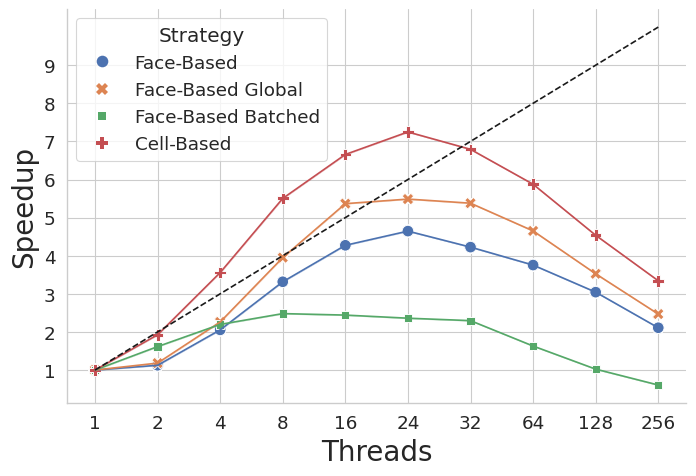

In [501]:
def scaling_speedup(data):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)

    with sb.plotting_context("paper", font_scale=1.5):
        plot = sb.relplot(data=data, x="threadindex", y="avg_speedup", kind="scatter", style="strategy", hue="strategy",s=70)
        axes = plot.axes.flat
        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data,
                x="threadindex",
                y="avg_speedup",
                hue="strategy",
                legend=False,   # avoid duplicate legends
                ax=ax
            )
            ax.tick_params(labelbottom=True)
            ax.set_xticks(list(range(1,11)))
            ax.set_xticklabels(labels=sorted(data["Threads"].unique()))
            ax.plot([1,10], [1,10], color='k',linestyle="dashed", label="Ideal Speedup")
            ax.set_yticks(list(range(1,10)))
        handles, labels = axes[0].get_legend_handles_labels()
        plot.legend.remove()
        plt.ylabel("Speedup", fontsize=20)
        plt.xlabel("Threads", fontsize=20)

        axes[0].legend(handles, cpu["strategy_display"].unique(), loc="upper left",
                        title="Strategy")
        
        # plt.xscale("log")
        plt.tight_layout()
    plt.savefig("../figures/cpuStrongscalingSpeedup.svg")
scaling_speedup(cpu)

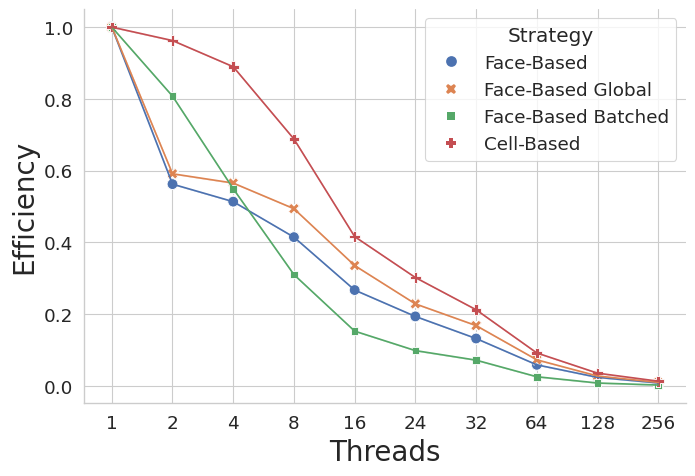

In [497]:
def scaling_efficiency(data):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.5):

        plot = sb.relplot(data=data, x="threadindex", y="avg_efficiency", kind="scatter", style="strategy", hue="strategy", s=60)
        axes = plot.axes.flat

        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data,
                x="threadindex",
                y="avg_efficiency",
                hue="strategy",
                legend=False,   # avoid duplicate legends
                ax=ax
            )
            ax.tick_params(labelbottom=True)
            ax.set_xticks(list(range(1,11)))
            ax.set_xticklabels(labels=sorted(data["Threads"].unique()))
            ax.set_xlabel("Threads")
        handles, labels = axes[0].get_legend_handles_labels()
        sb.move_legend(plot, "upper right", fancybox=True)
        plot.legend.remove()
        plt.ylabel("Efficiency", fontsize=20)
        plt.xlabel("Threads", fontsize=20)
        axes[0].legend(handles,  cpu["strategy_display"].unique(), loc="upper right",
                        title="Strategy")

        plt.tight_layout()
    plt.savefig("../figures/cpuStrongscalingEfficiency.svg")
scaling_efficiency(cpu)

In [ ]:
scaling_efficiency2(cpu)

In [ ]:
plot = sb.relplot(data=base_df, x="logthp1", y="ms_normed", kind="line", hue="strategy", err_style=None)
axes = plot.axes.flat

for i, ax in enumerate(axes):
    ax.set_title(f"{strats[i].capitalize()}")
    ax.tick_params(labelbottom=True)
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=base_df["Threads"].unique())
    ax.set_xlabel("Threads")
    ax.set_yscale("log")
plt.suptitle("Strong Scaling: Average over all case sizes")
plt.tight_layout()

In [ ]:
base_df

In [ ]:
import matplotlib.ticker as ticker


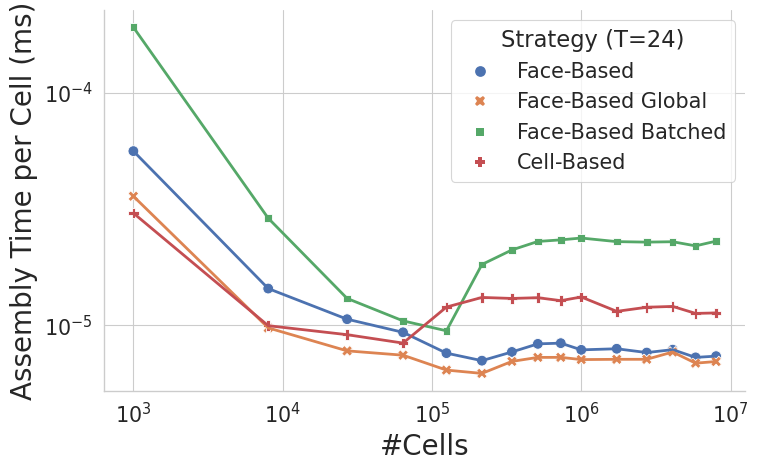

In [496]:
def nthreads(data, nthreads=32):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        
        plot = sb.relplot(data=data[data["Threads"]==nthreads], x="cells", y="ms_normed", kind="scatter", hue="strategy_display", style="strategy_display", s=60)
        axes = plot.axes.flat

        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data[data["Threads"]==nthreads],
                x="cells",
                y="ms_normed",
                hue="strategy_display",
                legend=False,   # avoid duplicate legends
                linewidth=2,
                ax=ax
            )
            # ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
            ax.set_yscale("log")
            ax.set_xscale("log")
        plot.legend.remove()
        plt.ylabel("Assembly Time per Cell (ms)", fontsize=20)
        plt.xlabel("#Cells", fontsize=20)
        labels = axes[0].get_legend_handles_labels()[1]
        handles, labels = axes[0].get_legend_handles_labels()
        plt.legend().set_title(f"Strategy (T={nthreads})") 
        plt.tight_layout()
    plt.savefig(f"../figures/T{nthreads}overCells.svg")
nthreads(cpu, 24)

In [ ]:
sb.barplot(base_df[(base_df["Threads"]>=8)&(base_df["Threads"] <= 64)], x="strategy", y="ms_normed", hue="strategy", errorbar=None)

In [ ]:
sb.barplot(data=base_df[base_df["Threads"] == 32], x="strategy", y="ms_normed", hue="strategy", errorbar=None)


In [ ]:
sb.barplot(base_df, x="strategy", y="ms_normed", hue="strategy", errorbar=None)

In [ ]:
scaling_efficiency(cellbased)
scaling_speedup(cellbased)

In [ ]:
threads32(cellbased)

In [ ]:
p = sb.relplot(data=cellbased, x="logthp1", y="ms_normed", kind="line", )
p.set(yscale="log")

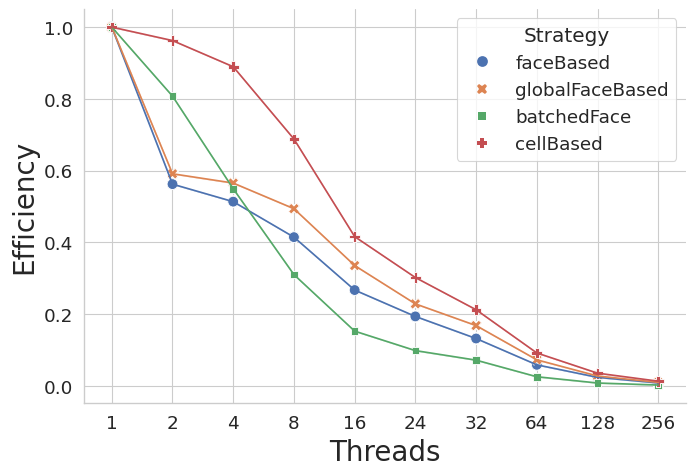

In [427]:
scaling_efficiency(cpu)

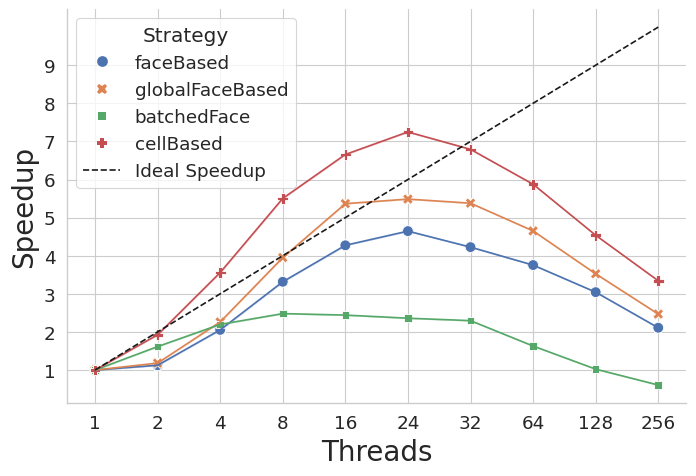

In [423]:
scaling_speedup(cpu)

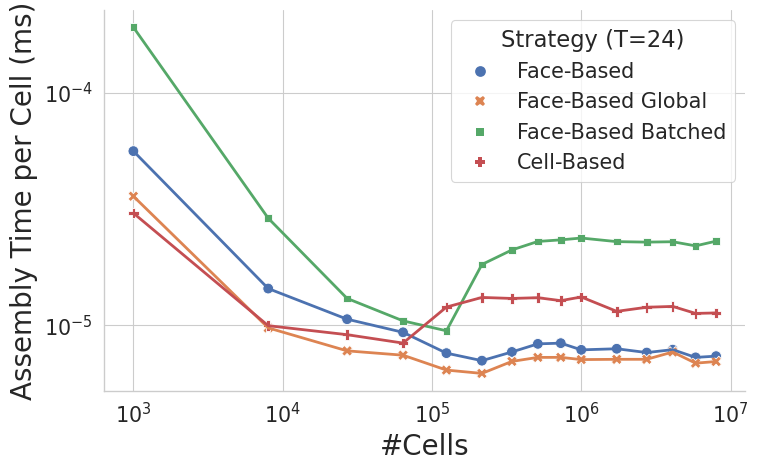

In [425]:
nthreads(cpu, 24)

In [ ]:
nthreads(cpu, 64)

In [ ]:
p = sb.relplot(data=cpu[cpu["Threads"]==32], x="cells", y="ms_normed", hue="strategy", kind="scatter")
axes = p.axes.flat
for i, ax in enumerate(axes):
    sb.lineplot(
        data=cpu[cpu["Threads"]==32],
        x="cells",
        y="ms_normed",
        hue="strategy",
        legend=False,   # avoid duplicate legends
        ax=ax
    )
    ax.tick_params(labelbottom=True)
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=cpu["Threads"].unique())
    ax.set_xlabel("Threads")
p.set(yscale="log", xscale="log")
p.legend.remove()

p.set(ylabel="Assembly Time per Cell (ms)", xlabel="#Cells")
labels = axes[0].get_legend_handles_labels()[1]
handles, labels = axes[0].get_legend_handles_labels()
plt.legend().set_title("Strategy (T=32)") 
plt.tight_layout()

In [ ]:
t = pd.read_csv("test.csv")

In [ ]:
t["#Blocks per SM"] = t["blocksPerSM"].apply(lambda x: f"{int(x)}")
t["blocksPerSMINT"] = t["blocksPerSM"].apply(lambda x: int(x))
t["workgroupsize"] = t["workgroupsize"].apply(lambda x: int(x))
t["avg_speedup"] = t.groupby("blocksPerSM")[
    "time_s"
].transform("mean")
t["Time (ms)"] = t["time_s"] * 100

In [ ]:
p2 = sb.relplot(data=t, x="workgroupsize", y="Time (ms)", style="#Blocks per SM", hue="#Blocks per SM", height=10, kind="scatter", s=100)
axes = p2.axes.flat
for ax in axes:
    sb.lineplot(
        data=t, 
        x="workgroupsize", 
        y="Time (ms)", 
        legend=False,   # avoid duplicate legends
        linewidth=1,
        c="black",
        ax=ax,
    )
p2.set(xlabel="#Threads per Block")

In [ ]:
p3 = sb.boxplot(data=t[t["blocksPerSMINT"]<24], x="blocksPerSMINT", y="time_s")
p3.set(yscale="log")

In [502]:
gpu = pd.read_csv("../results/gpuScaling.csv", skip_blank_lines=True)


In [515]:
gpu["cells"] = [int(x.rsplit("/", 2)[1]) ** 3 for x in gpu["case_long"]]
mapping = {
        "faceBased": "Face-Based",
        "globalFaceBased": "Face-Based Global",
        "batchedFace": "Face-Based Batched",
        "cellBased": "Cell-Based",
        "optimal": "Ideal Speedup",
    }
gpu["ms_normed"] = gpu["time_mean_ms"] / gpu["cells"]
gpu["#Threads per block"] = gpu["variant"].apply(lambda x: x.split("-")[1])
gpu["tpb"] = gpu["variant"].apply(lambda x: int(x.split("-")[1]))
gpu["strategy_display"] = [mapping[s] for s in gpu["strategy"]]


In [ ]:
[str(x) for x in sorted(gpu["tpb"].unique())]

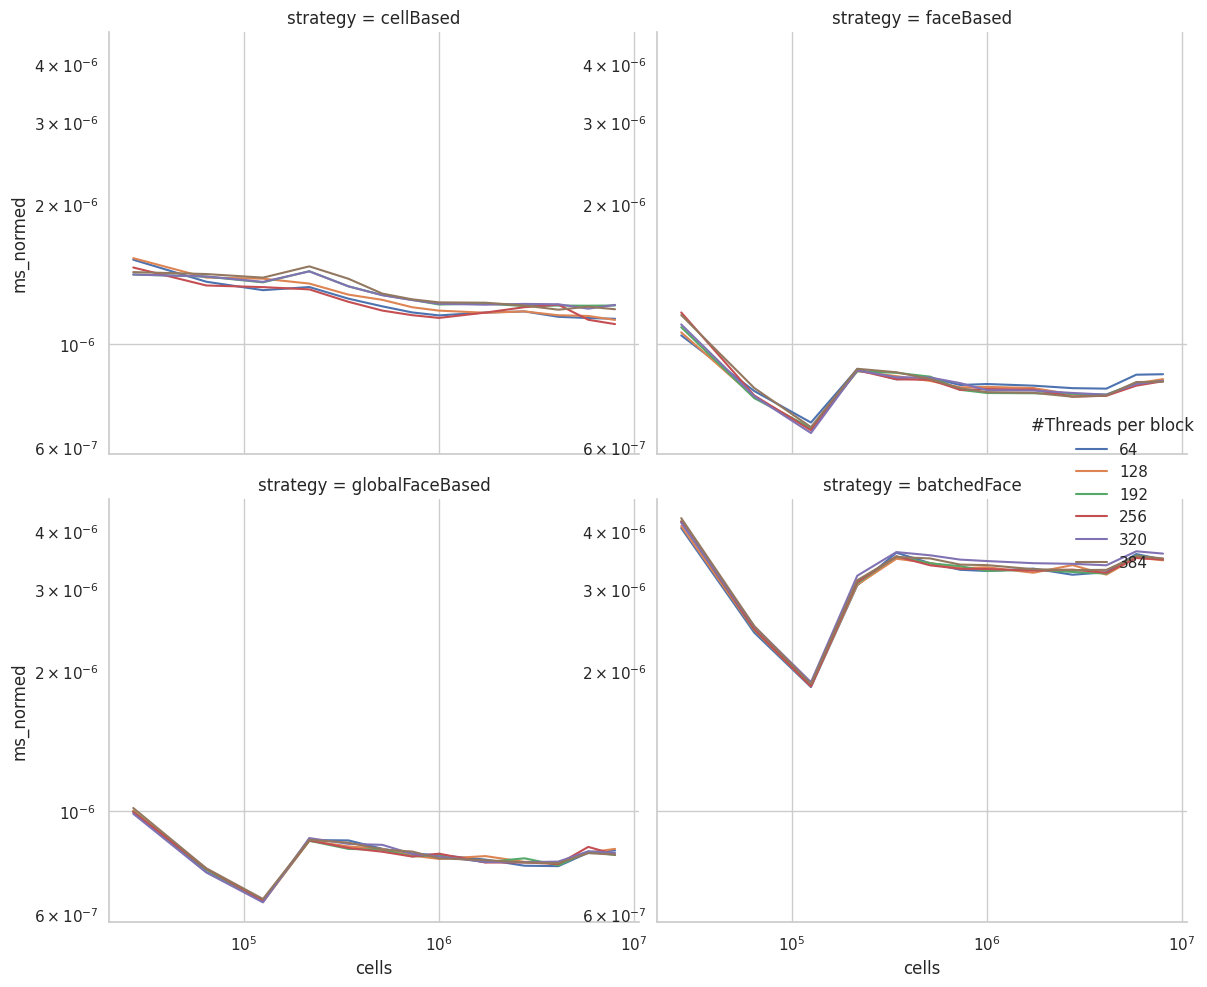

In [516]:
sb.set_style("whitegrid")
sb.color_palette("deep", 8)

p = sb.relplot(data=gpu[gpu["cells"]>20**3], x="cells", y="ms_normed", col="strategy", col_wrap=2,hue="#Threads per block", kind="line", hue_order=['64', '128', '192', '256', '320', '384'])
axes = p.axes.flat
plt.tight_layout()
p.set(yscale="log", xscale="log")

In [ ]:
def ms_normed(data, nthreads=32):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        
        plot = sb.relplot(data=data[data["Threads"]==nthreads], x="cells", y="ms_normed", kind="scatter", hue="strategy_display", style="strategy_display", s=60)
        axes = plot.axes.flat

        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data[data["Threads"]==nthreads],
                x="cells",
                y="ms_normed",
                hue="strategy_display",
                legend=False,   # avoid duplicate legends
                linewidth=2,
                ax=ax
            )
            # ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
            ax.set_yscale("log")
            ax.set_xscale("log")
        plot.legend.remove()
        plt.ylabel("Assembly Time per Cell (ms)", fontsize=20)
        plt.xlabel("#Cells", fontsize=20)
        labels = axes[0].get_legend_handles_labels()[1]
        handles, labels = axes[0].get_legend_handles_labels()
        plt.legend().set_title(f"Strategy (T={nthreads})") 
        plt.tight_layout()
    plt.savefig(f"../figures/T{nthreads}overCells.svg")
nthreads(cpu, 24)

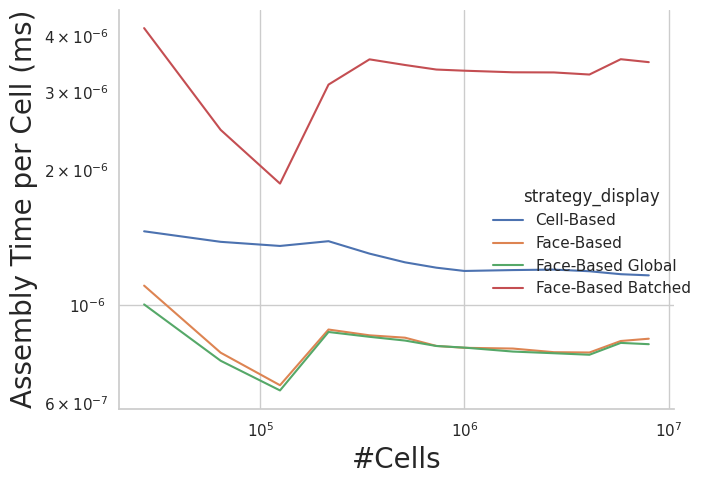

In [ ]:
sb.set_style("whitegrid")
sb.color_palette("deep", 8)

p = sb.relplot(data=gpu[gpu["cells"]>20**3], x="cells", y="ms_normed",err_style=None, kind="line", hue="strategy_display")
axes = p.axes.flat

p.set(yscale="log", xscale="log")
plt.ylabel("Assembly Time per Cell (ms)", fontsize=20)
plt.xlabel("#Cells", fontsize=20)
plt.tight_layout()